In [1]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

import functools as ft


In [2]:
# Leyendo geoDF de cuadrantes y creando geoDF de Sectores
IDs_cuadrantes_sectores= pd.read_csv("Data/Raw/IDs_cuadrantes_sectores.csv")
cuadrantes= gpd.read_file("Data/Raw/cuadrantes").to_crs("EPSG:6372")


cuadrantes= cuadrantes.merge(IDs_cuadrantes_sectores)
cuadrantes.zona= cuadrantes.zona.map({'PONIENTE': "P", 'CENTRO': "C", 'NORTE': "N", 'SUR': "S", 'ORIENTE': "O"})
cuadrantes.drop(columns= ["geo_shp", 'g_pnt_2'], inplace= True)
#cuadrantes.drop(columns= "geometry").to_csv("cuadrantes.csv")

sectores= cuadrantes.dissolve(by='sector').drop(columns= ['_id', 'id', 'no_regn', 'no_cdrn', "cuadrante_id"]).reset_index()
sectores.set_index("sector_id", inplace= True)


<Axes: >

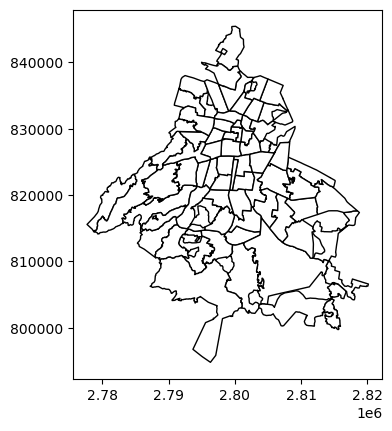

In [3]:
sectores.plot(color= "white", edgecolor='black')

In [4]:
# Leyendo Carpetas 

local_file = Path("Data/Raw/carpetasFGJ_acumulado_2025_01.csv")
url = "https://datos.cdmx.gob.mx/datastore/dump/35e87ce4-8e40-4de4-8dac-0b59645c13eb?bom=True"

if local_file.exists():
    print("Reading local file...")
    carpetas = pd.read_csv(local_file)
else:
    print("Local file not found. Downloading from URL...")
    carpetas = pd.read_csv(url)

carpetas.dropna(subset= ["latitud", "longitud", "fecha_inicio", "fecha_hecho"], axis=0, inplace= True)
# carpetas= carpetas[carpetas.categoria_delito != 'HECHO NO DELICTIVO']

# Quitamos estas columns (Aunque alcaldía_hecho es relevante. Se puede calcular por las coordenadas)
cols2drop= ['competencia', 'competencia', 'fiscalia', 
            'agencia','unidad_investigacion', 'colonia_hecho', 
            'colonia_catalogo','alcaldia_hecho', 'alcaldia_catalogo', 
            'municipio_hecho',]

carpetas.drop(columns= cols2drop, inplace= True)


# Convirtiendo a Geopandas
carpetas = gpd.GeoDataFrame(
    carpetas, 
    geometry=gpd.points_from_xy(carpetas.longitud, carpetas.latitud),
    crs="EPSG:4326"
).to_crs("EPSG:6372")

# Creando columnas datetime para hecho de delito y apertura de carpeta
carpetas["datetime_hecho"]= pd.to_datetime(
    carpetas["fecha_hecho"].str.split().str[0] + " " + carpetas["hora_hecho"],
    errors="coerce"
)

carpetas["datetime_inicio"]= pd.to_datetime(
    carpetas["fecha_inicio"].str.split().str[0] + " " + carpetas["hora_inicio"],
    errors="coerce"
)

# Quitando la hora de las fechas que tienen info extra
carpetas["fecha_hecho"] = pd.to_datetime(carpetas["fecha_hecho"], errors="coerce").dt.normalize()
carpetas["fecha_inicio"] = pd.to_datetime(carpetas["fecha_inicio"], errors="coerce").dt.normalize()

# Quitando minutos de las horas para simplificar
carpetas["hora_hecho"]= carpetas["hora_hecho"].str.split(":").str[0]
carpetas["hora_inicio"]= carpetas["hora_inicio"].str.split(":").str[0]


Reading local file...


/tmp/ipykernel_389807/47196925.py:8: DtypeWarning: Columns (10,17) have mixed types. Specify dtype option on import or set low_memory=False.
  carpetas = pd.read_csv(local_file)


#### Nota 1: `delito` tiene muchos valores únicos, por lo que `categoria_delito` puede ser una mejor variable target.
#### Nota 2: Existe la categoría `"HECHO NO DELICTIVO"` y `"DELITO DE BAJO IMPACTO"`. Creo que es buena idea quitar esto de nuestra variable target, pero tal vez funcionen como variables explicativas.
#### Nota 3: `"FEMINICIDIO"` y `"PLAGIO O SECUESTRO"` son `categoria_delito` con una sola carpeta. Por lo que hay que juntarlas con `"HOMICIDIO DOLOSO"` y `"SECUESTRO"` respectivamente.

In [5]:
carpetas.delito.nunique()

356

In [6]:
carpetas.groupby("categoria_delito").apply(lambda x: len(x)).sort_values(ascending= False)

/tmp/ipykernel_389807/1889218652.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  carpetas.groupby("categoria_delito").apply(lambda x: len(x)).sort_values(ascending= False)


categoria_delito
DELITO DE BAJO IMPACTO                                     1640648
ROBO A TRANSEUNTE EN VÍA PÚBLICA CON Y SIN VIOLENCIA        102890
ROBO DE VEHÍCULO CON Y SIN VIOLENCIA                         85960
HECHO NO DELICTIVO                                           65181
ROBO A NEGOCIO CON VIOLENCIA                                 27785
ROBO A REPARTIDOR CON Y SIN VIOLENCIA                        16427
ROBO A PASAJERO A BORDO DEL METRO CON Y SIN VIOLENCIA        14662
VIOLACIÓN                                                    12521
HOMICIDIO DOLOSO                                              9017
ROBO A PASAJERO A BORDO DE MICROBUS CON Y SIN VIOLENCIA       6212
LESIONES DOLOSAS POR DISPARO DE ARMA DE FUEGO                 5772
ROBO A CASA HABITACIÓN CON VIOLENCIA                          4169
ROBO A CUENTAHABIENTE SALIENDO DEL CAJERO CON VIOLENCIA       3064
ROBO A PASAJERO A BORDO DE TAXI CON VIOLENCIA                 1859
ROBO A TRANSPORTISTA CON Y SIN VIOLENCIA     

Las columnas `[anio/mes,decha, etc]_inicio` habland de la apertura de la carpeta de investigación, mientras que `[anio/mes,decha, etc]_hecho` se refieren a cuando ocurrió el delito

#### Nota 4: Podemos recuperar la categoría `"FEMINICIDIO"` utilizando la columna delito

In [7]:
carpetas[carpetas.categoria_delito== "HOMICIDIO DOLOSO"].delito.unique()

array(['HOMICIDIOS INTENCIONALES (OTROS)', 'HOMICIDIO POR ARMA DE FUEGO',
       'HOMICIDIO POR ARMA BLANCA', 'HOMICIDIO POR GOLPES', 'FEMINICIDIO',
       'HOMICIDIO POR AHORCAMIENTO',
       'FEMINICIDIO POR DISPARO DE ARMA DE FUEGO',
       'FEMINICIDIO POR ARMA BLANCA', 'FEMINICIDIO POR GOLPES',
       'HOMICIDIO POR INMERSION'], dtype=object)

In [8]:
# esta función cuenta cuantos puntos (points) caen en cada poligono (polygons) y regresa una Serie 
def count_points_in_polygons(polygons, points):

    if polygons.crs != points.crs:
        points = points.to_crs(polygons.crs)

    polygons = polygons.copy()
    polygons["_polygon_id"] = range(len(polygons))

    joined = gpd.sjoin(
        points,
        polygons[["_polygon_id", "geometry"]],
        how="left",
        predicate="within"
    )

    return (
        joined.groupby("_polygon_id")
        .size()
        .reindex(polygons["_polygon_id"], fill_value=0)
        .set_axis(polygons.index)
        .astype(int)
    )

# Guardamos en delitos_por_sector la cuenta de cuantos delitos occurren por cada secor (agrupado por tipo de delito)
delitos_por_sector= sectores.copy(deep= True)

for delito, sub_df in carpetas.groupby("categoria_delito"):

    cuenta= count_points_in_polygons(sectores, sub_df)
    
    delitos_por_sector[delito]= cuenta
    

In [9]:
# Esta función regresa el ID del polígono donde cae cada punto.  
def get_polygon_for_points(polygons, points):


    if polygons.crs != points.crs:
        points = points.to_crs(polygons.crs)

    # Give the polygon index an explicit, unique column name
    polygons_tmp = polygons[["geometry"]].copy()
    polygons_tmp["_polygon_id"] = polygons_tmp.index

    joined = gpd.sjoin(
        points,
        polygons_tmp,
        how="left",
        predicate="within"
    )

    return joined["_polygon_id"].set_axis(points.index)

# Agregamos al df carpetas el secotr donde ocurrió cada delito
secto_por_carpeta= get_polygon_for_points(sectores, carpetas)
carpetas['sector']= secto_por_carpeta

cuadrante_por_carpeta= get_polygon_for_points(cuadrantes.set_index("cuadrante_id"), carpetas)
carpetas['cuadrante']= cuadrante_por_carpeta

carpetas["alcaldia"]= carpetas.sector.map(sectores.alcaldi)

In [10]:
# Guardamos carpetas con etiqueta de sector en un CSV
carpetas.to_csv("Data/Procesada/carpetas_procesadas.csv")

In [11]:
# OJO! HAY ANTES DE 2025 HAY POCAS CARPETAS!!!! TAL VEZ SEA BUENA IDEA QUITAR AÑOS ANTERIORES
carpetas.anio_hecho.value_counts().head(20)

anio_hecho
2018.0    245854
2019.0    236830
2022.0    224393
2023.0    224055
2017.0    219078
2021.0    216486
2024.0    203287
2020.0    197627
2016.0    188034
2015.0     15498
2025.0     11828
2014.0      4307
2013.0      2252
2012.0      1622
2011.0      1136
2010.0       937
2009.0       547
2008.0       503
2007.0       345
2006.0       296
Name: count, dtype: int64

In [12]:
# Quitamos carpetas de delitos ocurridos ANTES de 2015
carpetas= carpetas[carpetas.anio_hecho >= 2015]

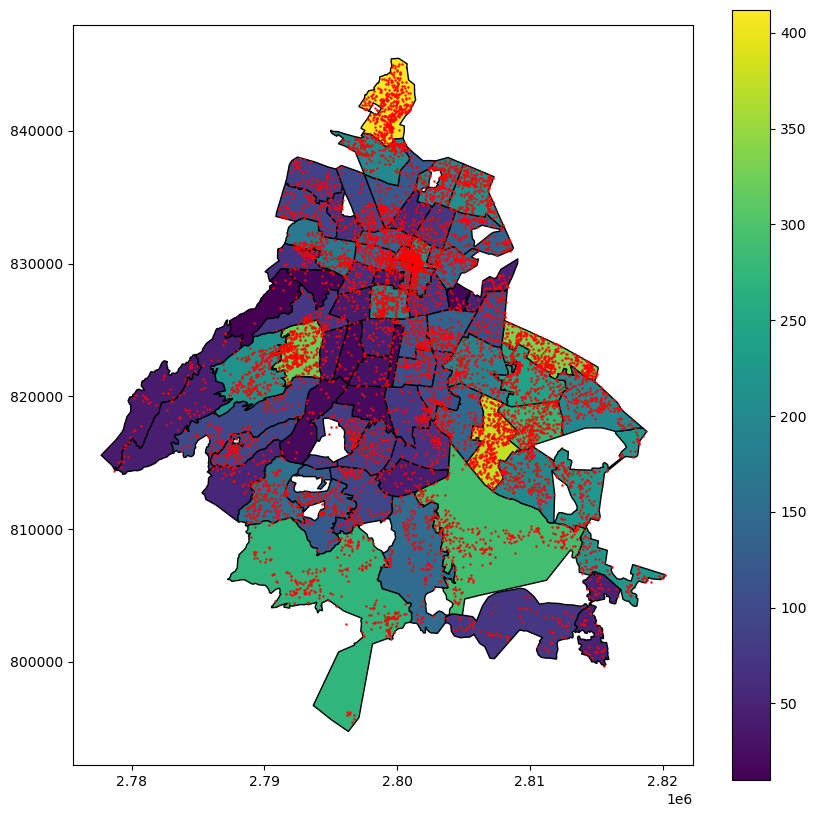

In [13]:
# Ejemplo: Mapa de homicidios dolosos (todo el año)

fig, ax = plt.subplots(figsize=(10, 10))
#sectores.plot(ax=ax, color="lightgrey", edgecolor="white", zorder=1)

delitos_por_sector.plot(ax=ax, column= "HOMICIDIO DOLOSO", legend=True, edgecolor='black')
carpetas[carpetas.categoria_delito=="HOMICIDIO DOLOSO"].plot(ax=ax, markersize= 0.5, color= "red")

plt.show()

# Agregamos data de SCITEL (INEGI) a sectores

La información de SCITEL viene por AGEBs y Manzanas. En este caso usamos AGEBs. 

Las AGEBS y los Sectores son poligonos distintos que no siempre se traslapan. Para asignar los indicadores de AGEB a los Sectores de forma simple calculamos el centroide de las AGEBs y definimos la población de un sector como la suma la población de las AGEBS cuyos centroides estén dentro de cada sector.

Quitamos indicadores promedio o tasas para simplificar los cálculos. Esto pueden ser calculados a nivel secor posteriormente.

### Nota 1: Muhca de las columnas son redundantes y/o pueden ser irrelevantes.
### Nota 2: Hay documentación de las columnas en en Data/Raw/SCITEL.


In [14]:
# Leemos polígonos de AEGBs de la CDMX 
# https://datos.cdmx.gob.mx/dataset/poligonos-de-manzanas-de-la-ciudad-de-mexico/resource/76c6456d-660c-4e78-81c3-44ee51dcae10
agebs= gpd.read_file( "Data/Raw/AGEB_CDMX.json").to_crs("EPSG:6372").set_index("CVEGEO")


# Leemos data del censo 2020
# https://www.inegi.org.mx/app/scitel/Default?ev=10
data_inegi= pd.read_csv("Data/Raw/SCITEL/RESAGEBURB_09CSV20.csv")
# Nos quedamos por la info por AGEB
data_inegi= data_inegi[  (data_inegi.NOM_LOC =="Total AGEB urbana") ] 

# Creamos nuevo index para hacer match con geoDF agebs
# El nuevo index está formado por las claves de entidad, municipio, localidad y AGEB (equivalente a CVEGEO en agebs)
data_inegi["CVEGEO"]= data_inegi["ENTIDAD"].astype(str).str.zfill(2) + \
data_inegi["MUN"].astype(str).str.zfill(3) + \
data_inegi["LOC"].astype(str).str.zfill(4) + \
data_inegi["AGEB"].astype(str).str.zfill(4)

data_inegi.set_index("CVEGEO", inplace= True)


# Juntamos los poligonos de las AGEBS con la data del INEGI.
# Existen 2 AGEBS que no tiene data de inegi, las omitimos. (POSIBLE ALTERNATIVA, IMPUTAR USANDO VECINOS)

agebs= pd.concat([agebs, data_inegi], axis=1).dropna()


<Axes: >

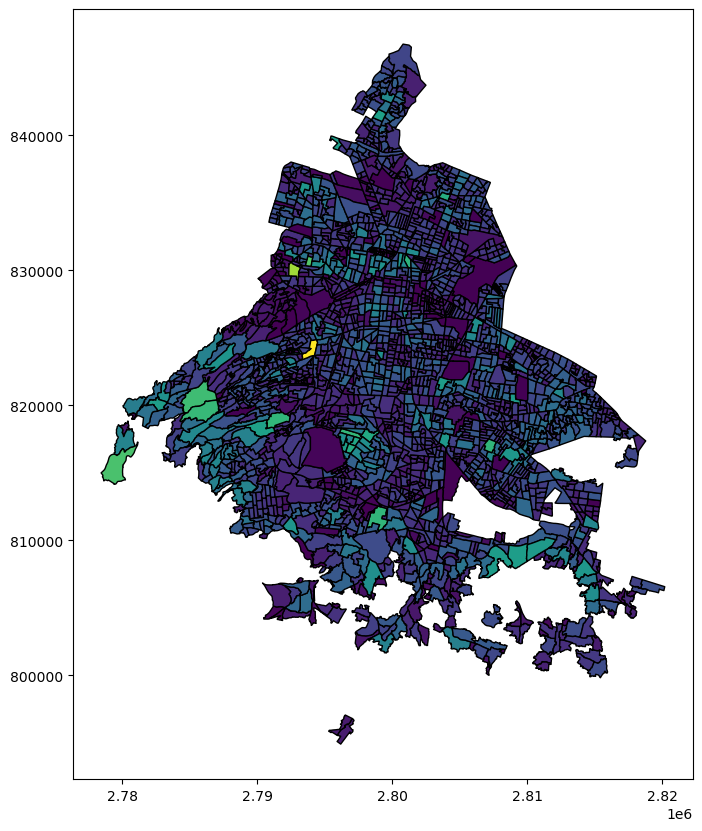

In [15]:
# Así se ven las AGEBs (Ejemplo de población total)

fig, ax = plt.subplots(figsize=(10, 10))
agebs.plot(ax= ax, column= "POBTOT", edgecolor='black')

In [16]:
# Sustituimos la columna "geometry" (con polígonos) de agebs por los centroides
agebs["geometry"]= agebs.centroid
# Asignamos un sector a cada AGEB
agebs["sector"]= get_polygon_for_points(sectores, agebs)

In [17]:
# Calculamos el total de los indicadores por sector.
# Quitamos columnas que no tienen sentido sumar
cols2ignore= ['CVE_ENT', 'CVE_MUN', 'CVE_LOC', 'CVE_AGEB', 'geometry', 'ENTIDAD',
       'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'AGEB', 'MZA'] + \
["REL_H_M", "PROM_HNV", "GRAPROES", "GRAPROES_F", "GRAPROES_M", "PROM_OCUP", "PRO_OCUP_C"]

# Se calcula la suma de indicadores por sector
data_por_sector= agebs.drop(columns= cols2ignore).groupby("sector").apply(lambda group: group.replace({"*": 0}).astype(int).sum(), include_groups=False )


In [18]:
# Guardamos data por sector como csv
data_por_sector.to_csv("Data/Procesada/SCITEL_por_sector.csv")

# Guardamos data por sector con polígonos (como gpkg)
pd.concat( [sectores, data_por_sector], axis=1).to_file("Data/Procesada/cuadrantes_con_SCITEL.gpkg")

In [19]:
asdfasdfasdfasdf

NameError: name 'asdfasdfasdfasdf' is not defined

# Experimentos (no es relevante pero quiero guardar el código)

In [ ]:

def daily_count_by_area(
    df,
    date_col,
    area_col,
    t0=None,
    t1=None
):
    """
    Count daily occurrences by area.

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame.
    date_col : str
        Name of the datetime/date column.
    area_col : str
        Name of the column identifying the area.
    t0 : datetime-like, optional
        Start date (inclusive).
    t1 : datetime-like, optional
        End date (inclusive).

    Returns
    -------
    pandas.DataFrame
        DataFrame with columns:
        [area_col, "dia", "count"]
    """

    data = df[[date_col, area_col]].copy()

    data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
    data = data.dropna(subset=[date_col, area_col])

    if t0 is not None:
        t0 = pd.Timestamp(t0)
        data = data[data[date_col] >= t0]

    if t1 is not None:
        t1 = pd.Timestamp(t1)
        data = data[data[date_col] <= t1]

    data["dia"] = data[date_col].dt.normalize()

    result = (
        data.groupby([area_col, "dia"])
        .size()
        .reset_index(name="count")
        .sort_values([area_col, "dia"])
        .reset_index(drop=True)
    )

    return result




resultado = daily_count_by_area(
    carpetas,
    date_col="fecha_hecho",
    area_col="sector",
    t0="2024-03-10",
    t1="2024-05-20"
)





In [ ]:


delitos_por_sector_dia= []

for delito, sub_df in carpetas.groupby("categoria_delito"):

    cuenta= resultado = daily_count_by_area( carpetas, date_col="fecha_hecho", area_col="sector",
                                             t0=None, t1=None )
    
    cuenta= cuenta.rename(columns= {"count": delito})

    delitos_por_sector_dia.append( cuenta )

delitos_por_sector_dia= ft.reduce(lambda left, right: pd.merge(left, right, on=['sector', "dia"], how= "outer"), delitos_por_sector_dia)



In [ ]:
carpetas.fecha_hecho.dt.year.value_counts().head(30)

In [ ]:
delitos_por_sector_dia

In [ ]:
from functools import reduce

result = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["area", "period"],
        how="outer"
    ),
    dfs
).fillna(0)

In [ ]:
pd.concat( delitos_por_sector_dia) 

In [ ]:
carpetas.categoria_delito.unique()

In [ ]:
delitos_por_sector_dia["SECUESTRO"]